In [117]:
import matplotlib.pyplot as plt
import numpy as np
from reservoirpy.observables import nrmse, rsquare
from reservoirpy.nodes import Ridge, NVAR
from pandas import read_csv
%matplotlib inline

In [118]:
data_time = read_csv('../Dataset/Lorenz_data.csv', usecols=[0])
time = data_time.values
time = time.astype('float32')

data_Lorenz = read_csv('../Dataset/Lorenz_data.csv', usecols=[1, 2, 3])
data_Lorenz = data_Lorenz.values
data_Lorenz = data_Lorenz.astype('float32')

data_Rossler = read_csv('../Dataset/Rossler_data.csv', usecols=[1, 2, 3])
data_Rossler = data_Rossler.values
data_Rossler = data_Rossler.astype('float32')

data_Chen = read_csv('../Dataset/Chen_data.csv', usecols=[1, 2, 3])
data_Chen = data_Chen.values
data_Chen = data_Chen.astype('float32')

data_Qi = read_csv('../Dataset/Qi_data.csv', usecols=[1, 2, 3])
data_Qi = data_Qi.values
data_Qi = data_Qi.astype('float32')

In [119]:
X = data_Lorenz
# X = 2 * (X - X.min()) / (X.max() - X.min()) - 1

total_steps = len(X)
warm_steps = round(0.05*total_steps)
train_steps = round(0.4*total_steps)
test_steps = round(0.55*total_steps)

In [120]:
nvar = NVAR(delay=2, order=2, strides=1)
readout = Ridge(3, ridge=2.5e-6)

model = nvar >> readout
model

'Model-17': Model('NVAR-17', 'Ridge-17')

In [121]:
Xi  = X[:train_steps+warm_steps-1]
dXi = X[1:train_steps+warm_steps] - X[:train_steps+warm_steps-1]

model = model.fit(Xi, dXi, warmup=warm_steps)

Running Model-17: 2249it [00:00, 5848.15it/s]<?, ?it/s]
Running Model-17: 100%|██████████| 1/1 [00:00<00:00,  2.60it/s]


Fitting node Ridge-17...


In [122]:
nvar.run(X[warm_steps+train_steps-2:warm_steps+train_steps])
u = X[warm_steps+train_steps]
res = np.zeros((test_steps, readout.output_dim))
for i in range(test_steps):
    u = u + model(u)
    res[i, :] = u

Running NVAR-17: 100%|██████████| 2/2 [00:00<00:00, 925.59it/s]


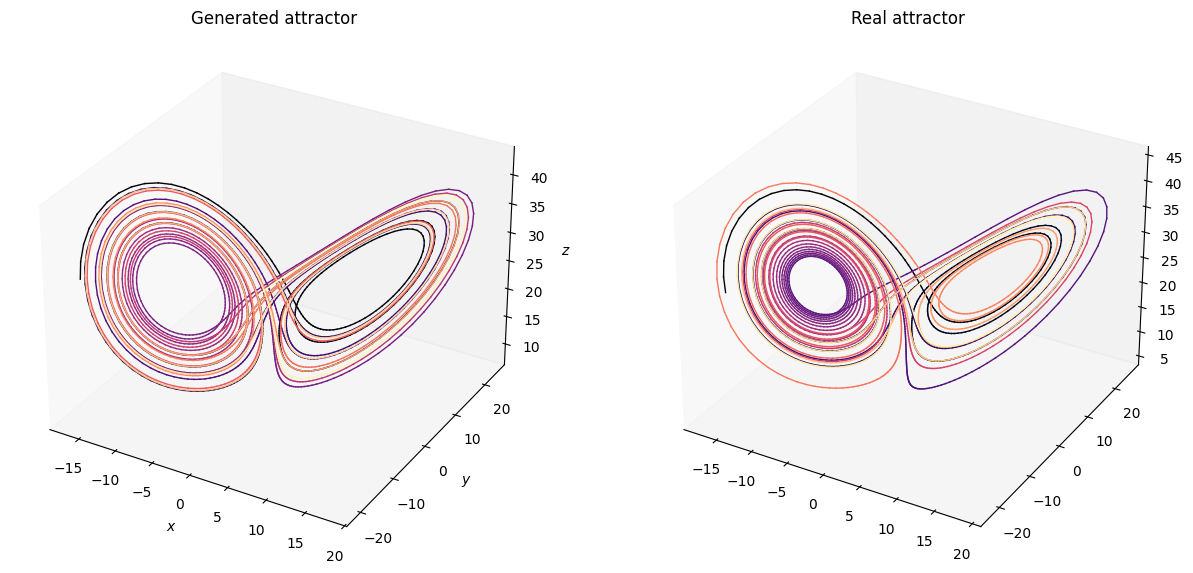

In [123]:
N = test_steps
Y = X[warm_steps+train_steps:]

fig = plt.figure(figsize=(15, 10))
ax  = fig.add_subplot(121, projection='3d')
ax.set_title("Generated attractor")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.grid(False)

for i in range(N-1):
    ax.plot(res[i:i+2, 0], res[i:i+2, 1], res[i:i+2, 2], color=plt.cm.magma(255*i//N), lw=1.0)

ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("Real attractor")
ax2.grid(False)

for i in range(N-1):
    ax2.plot(Y[i:i+2, 0], Y[i:i+2, 1], Y[i:i+2, 2], color=plt.cm.magma(255*i//N), lw=1.0)

In [142]:
# rsquare(Y, res), nrmse(Y, res)
error = res - Y
e = np.abs(np.mean(error, axis=1))
T = time[warm_steps+train_steps:]

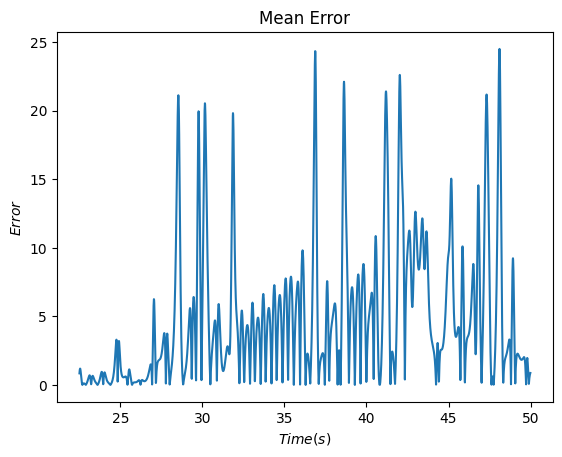

In [143]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(T, e)
ax.set_title("Mean Error")
ax.set_xlabel("$Time(s)$")
ax.set_ylabel("$Error$")
ax.grid(False)